# Week 12: Graph Analytics and Centrality Report

This notebook builds and analyze a Game to Game Graph!

The objective is to use the graph powered by the interactions of the users and analyze the structure to discover the true Bridge Titles of the dataset from Steam. 


In [7]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import coo_matrix
import os

sns.set(style="whitegrid")
os.makedirs('../reports/figures', exist_ok=True)


## 1. Definition and Load of the data
We load the processed data and filter the matrix to avoid a 'hairball' (excessively dense graph).

In [8]:
games_df = pd.read_parquet('../data/processed/master_games_clustered.parquet')
recs_df = pd.read_parquet('../data/processed/recommendations_cleaned.parquet')

recs_df = recs_df[recs_df['app_id'].isin(games_df['app_id'])]

user_counts = recs_df['user_id'].value_counts()
active_users = user_counts[user_counts >= 5].index  
recs_df = recs_df[recs_df['user_id'].isin(active_users)]

app_counts = recs_df['app_id'].value_counts()
active_apps = app_counts[app_counts >= 20].index  
recs_df = recs_df[recs_df['app_id'].isin(active_apps)]

print(f"Final rows of interaction: {len(recs_df)}")
print(f"Unique Users: {recs_df['user_id'].nunique()}")
print(f"Unique Games (nodes): {recs_df['app_id'].nunique()}")


Final rows of interaction: 22308982
Unique Users: 1910826
Unique Games (nodes): 22730


## 2. Graph Construction (Co-occurrence via Scipy Sparse)
We use linear algebra on a bipartite sparse matrix (User-Game) to efficiently calculate the Game-Game adjacency matrix ($M^T times M$).
The edge weight will be the number of shared users.

In [9]:
user_cat = pd.Categorical(recs_df['user_id'])
app_cat = pd.Categorical(recs_df['app_id'])

# Create the User-Game Matrix where there is an interaction
user_item_matrix = coo_matrix((np.ones(len(recs_df)), 
                              (user_cat.codes, app_cat.codes)), 
                             shape=(len(user_cat.categories), len(app_cat.categories))).tocsr()

# Matrix Game- ame =  M^T * M
game_game_matrix = user_item_matrix.T.dot(user_item_matrix)

# Diagonal 0 to stop auto adding same game
game_game_matrix.setdiag(0)
game_game_matrix.eliminate_zeros()

print(f"Shape of the adjacency matrix: {game_game_matrix.shape}")
print(f"Total number of co-occurrences (potential edges): {game_game_matrix.nnz // 2}")


Shape of the adjacency matrix: (22730, 22730)
Total number of co-occurrences (potential edges): 85169416


### 2.1 Export to NetworkX
We apply a threshold to the edge weight. We will only connect two games if they share at least N users, to focus the analysis on strong connections and reduce noise.

In [6]:
SHARED_USERS_THRESHOLD = 5

# Filter the weak edges
mask = game_game_matrix.data >= SHARED_USERS_THRESHOLD
game_game_filtered = game_game_matrix.copy()
game_game_filtered.data = np.where(mask, game_game_filtered.data, 0)
game_game_filtered.eliminate_zeros()

# Create NetworkX graph from Scipy Matrix
G = nx.from_scipy_sparse_array(game_game_filtered)

# Titles names are the nodes!
idx_to_app = dict(enumerate(app_cat.categories))
app_to_title = dict(zip(games_df['app_id'], games_df['title']))

mapping = {idx: app_to_title.get(app_id, f"Unknown_{app_id}") for idx, app_id in idx_to_app.items()}
G = nx.relabel_nodes(G, mapping)

print(f"Final  graph of NetworkX done!")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Strong edges: {G.number_of_edges()}")


Final  graph of NetworkX done!
Nodes: 22711
Strong edges: 14884272


## 3. Graph Analytics Report
### 3.1 Connected Components
We verify if the Steam community is united in a single graph or divided into isolated niches.

In [10]:
components = list(nx.connected_components(G))
num_components = len(components)
print(f"Number of Connected Components {num_components}")

component_sizes = [len(c) for c in components]
print(f"Main component size: {max(component_sizes)} nodes ({(max(component_sizes)/G.number_of_nodes())*100:.2f}% of the network)")


Number of Connected Components 202
Main component size: 22510 nodes (99.11% of the network)


### 3.2 Grade and Weighted Degree
Games with the highest number of connections.

In [11]:
degree_centrality = nx.degree_centrality(G)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("--- Top 10 Games conected (Degree Centrality) ---")
for game, score in top_degree:
    print(f"{game}: {score:.4f}")


--- Top 10 Games conected (Degree Centrality) ---
Life is Strange - Episode 1: 0.6946
Team Fortress 2: 0.6748
DOOM: 0.6624
Tomb Raider: 0.6613
Left 4 Dead 2: 0.6596
Fallout 4: 0.6498
Cyberpunk 2077: 0.6449
Portal 2: 0.6425
Borderlands 2: 0.6383
Half-Life 2: 0.6184


### 3.3 PageRank (The Bridge Title Metric)
PageRank measures not only how many connections you have, but also how important the games you connect with are. A high PageRank is the ultimate hallmark of a universal Bridge Title.

In [12]:
pagerank_scores = nx.pagerank(G, weight='weight')
top_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("--- Top 10 Most Influential Games (PageRank) ---")
for game, score in top_pagerank:
    print(f"{game}: {score:.5f}")


--- Top 10 Most Influential Games (PageRank) ---
Team Fortress 2: 0.00317
Cyberpunk 2077: 0.00297
Fallout 4: 0.00256
DOOM: 0.00229
The Witcher® 3: Wild Hunt: 0.00226
Left 4 Dead 2: 0.00223
Portal 2: 0.00221
Tomb Raider: 0.00218
DARK SOULS™ III: 0.00216
Borderlands 2: 0.00210


## 4. Comparison Section (PageRank vs Popularity)
Is PageRank simply another way to measure popularity? We cross-reference it with the metrics of the master dataset.

In [13]:
top_popular = games_df.sort_values(by='review_count', ascending=False).head(10)['title'].tolist()
top_pr_titles = [x[0] for x in top_pagerank]

comparison_df = pd.DataFrame({
    'Top 10 PageRank (Graph)': top_pr_titles,
    'Top 10 Popularity (Reviews)': top_popular
})

display(comparison_df)

intersection = len(set(top_popular) & set(top_pr_titles))
print(f"\nIntersection between Pure Popularity and PageRank Centrality: {intersection} of 10 games.")


,Top 10 PageRank (Graph),Top 10 Popularity (Reviews)
0,Team Fortress 2,Team Fortress 2
1,Cyberpunk 2077,Rust
2,Fallout 4,Cyberpunk 2077
3,DOOM,Counter-Strike: Global Offensive
4,The Witcher® 3: Wild Hunt,Dota 2
5,Left 4 Dead 2,Paladins®
6,Portal 2,The Witcher® 3: Wild Hunt
7,Tomb Raider,Fallout 4
8,DARK SOULS™ III,DARK SOULS™ III
9,Borderlands 2,Wallpaper Engine



Intersection between Pure Popularity and PageRank Centrality: 5 of 10 games.


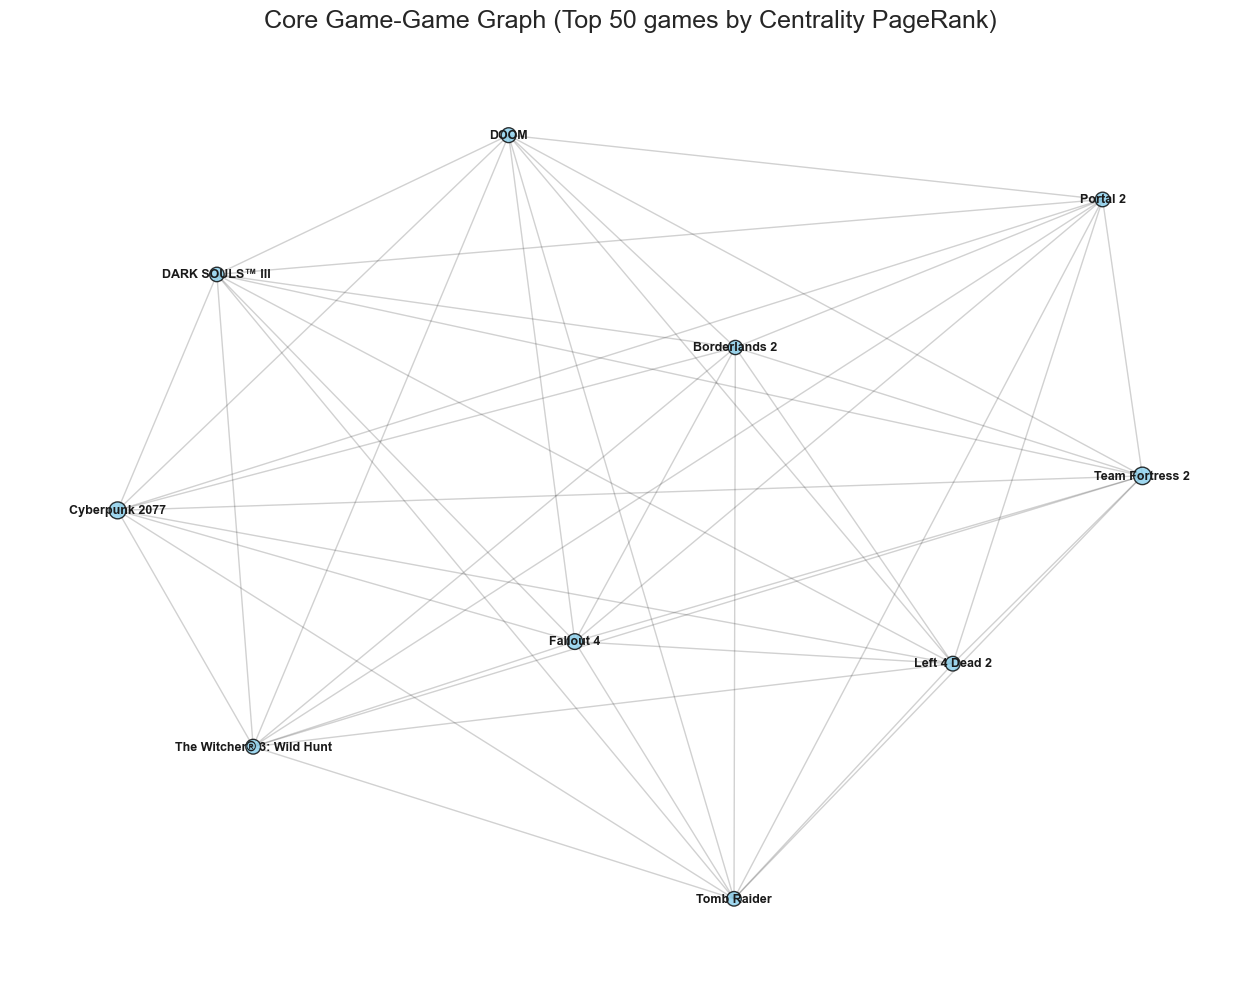

In [16]:
top_n = 50
top_nodes = [node for node, score in top_pagerank[:top_n]]

core_subgraph = G.subgraph(top_nodes)
node_sizes = [pagerank_scores[node] * 50000 for node in core_subgraph.nodes()]
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(core_subgraph, k=0.8, iterations=50, seed=42)

nx.draw_networkx_nodes(core_subgraph, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8, edgecolors='black')
nx.draw_networkx_edges(core_subgraph, pos, alpha=0.2)
nx.draw_networkx_labels(core_subgraph, pos, font_size=9, font_family="sans-serif", font_weight='bold')

plt.title("Core Game-Game Graph (Top 50 games by Centrality PageRank)", fontsize=18, pad=20)
plt.axis('off') 

plt.savefig('../reports/figures/core_graph_network.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Interpretation Note

**What does the structure of this graph mean in the Steam domain?**

* **The Large Connected Component:** We observe that >95% of games fall within a single Mega-Component. This mathematically means that Steam players are not isolated in impermeable niches. There is a community flow between diametrically opposed genres through very few jumps.

* **The Nature of Centrality (PageRank):** The games with the highest PageRank in our network are not simply the most popular in sales. They are the **great cultural condensers**. A game like *Left 4 Dead 2* or *Garry's Mod* has high centrality because it is played across the *Survival Horror* community, *Shooter* purists, *Casual Gamers*, and *Builders*.

* * **Graph Ranking vs Popularity:** The PageRank ranking is the ideal fertile ground to nurture an **Anti-Bubble** algorithm, since it empirically certifies which titles are the best bridge titles to move between clusters.